### Diabetes database

In [1]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'

In [3]:
df = df.dropna(subset=['Outcome'])
df.shape

(768, 9)

In [4]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))

Accuracy: 0.7922077922077922
Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [7]:
import os
OUTPUT_DIR = "outputs_diabetes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

from sklearn.tree import export_graphviz
import graphviz
import shutil

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/diabetes_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT:", out_path)
else:
    graph.render(f"{OUTPUT_DIR}/diabetes_tree", format="png", cleanup=True)

Graphviz not found in PATH. Saved DOT: outputs_diabetes/diabetes_tree.dot


### Diabetes — LIME Explanations


In [8]:
!pip install lime


In [9]:
import lime
import lime.lime_tabular

# Diabetes has only numeric features — no categorical dummies
cat_feature_idx = []

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)


In [10]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_diab = X_train.columns.tolist()

# Pick one diabetic and one non-diabetic from the test set
diabetic_idx = test_labels[test_labels == 1].index[0]
no_diabetic_idx = test_labels[test_labels == 0].index[0]

print(f"Diabetic instance (test index {diabetic_idx}):")
print(dict(zip(feature_names_diab, X_test_arr[diabetic_idx])))
print(f"\nNon-diabetic instance (test index {no_diabetic_idx}):")
print(dict(zip(feature_names_diab, X_test_arr[no_diabetic_idx])))


Diabetic instance (test index 10):
{'Pregnancies': np.float64(10.0), 'Glucose': np.float64(111.0), 'BloodPressure': np.float64(70.0), 'SkinThickness': np.float64(27.0), 'Insulin': np.float64(0.0), 'BMI': np.float64(27.5), 'DiabetesPedigreeFunction': np.float64(0.141), 'Age': np.float64(40.0)}

Non-diabetic instance (test index 0):
{'Pregnancies': np.float64(6.0), 'Glucose': np.float64(98.0), 'BloodPressure': np.float64(58.0), 'SkinThickness': np.float64(33.0), 'Insulin': np.float64(190.0), 'BMI': np.float64(34.0), 'DiabetesPedigreeFunction': np.float64(0.43), 'Age': np.float64(43.0)}


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


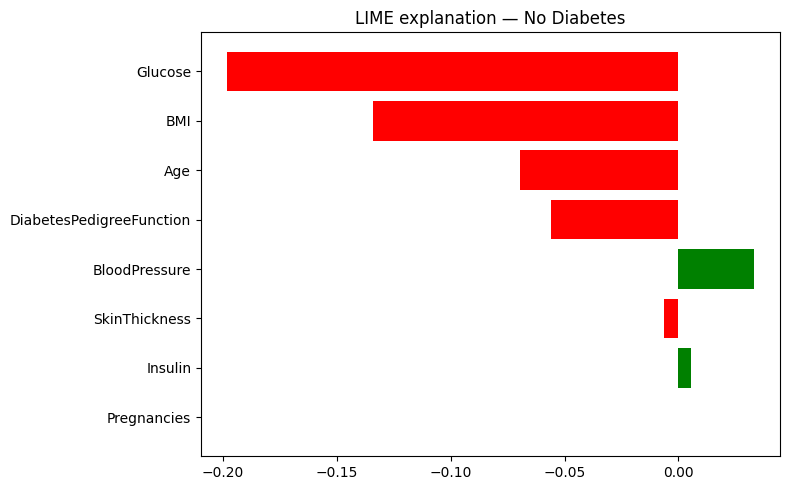

In [11]:
import matplotlib.pyplot as plt

exp_no_diab = lime_explainer.explain_instance(
    X_test_arr[no_diabetic_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_diab.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — No Diabetes")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_no_diabetes.png", dpi=150)
plt.show()


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


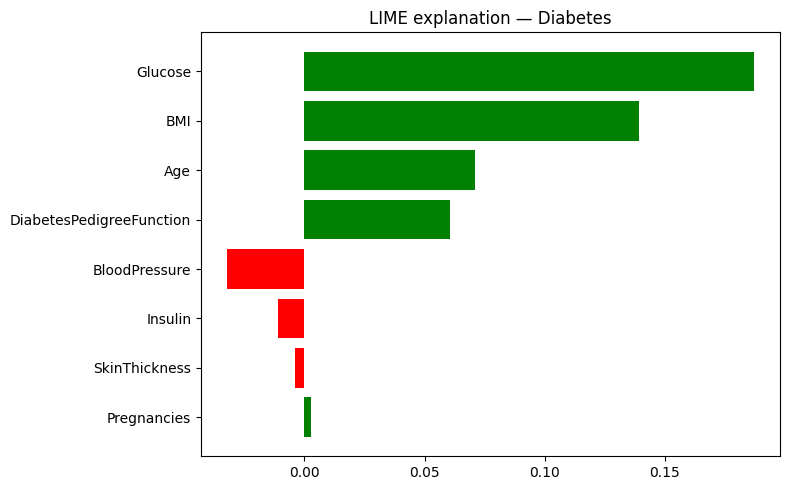

In [12]:
exp_diab = lime_explainer.explain_instance(
    X_test_arr[diabetic_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_diab.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Diabetes")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_diabetes.png", dpi=150)
plt.show()


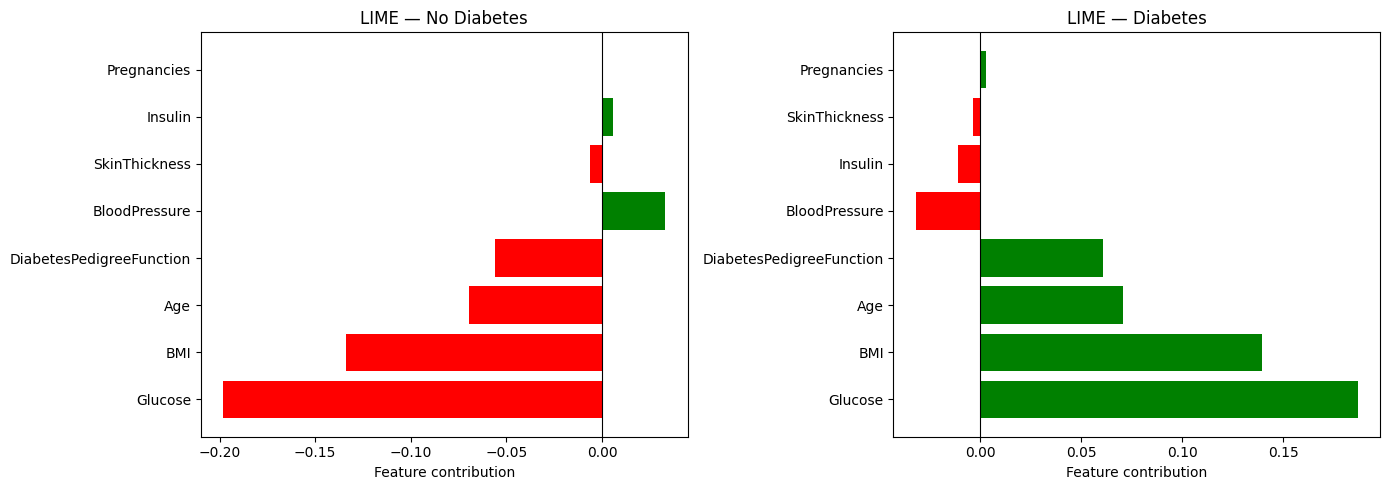

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_diab, 0, "No Diabetes"),
    (axes[1], exp_diab,    1, "Diabetes"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_lime_comparison.png", dpi=150)
plt.show()


#### Diabetes — LIME Global Ranking (multi-instance)


In [14]:
# ── LIME Global Ranking: aggregate over 50 test instances (Diabetes) ──
import re, numpy as np, pandas as pd, os

_OUTPUT_DIR_DIAB = 'outputs_diabetes'
_N_LIME = min(50, len(X_test_arr))

# feature_names_diab was set earlier (X_train.columns.tolist())
_feat_set_diab = set(feature_names_diab)

def _parse_lime_feature(condition_str, known_features):
    """Extract the base feature name from a LIME condition string."""
    # Try longest-match from known_features first
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    # Fallback: split on comparison operators
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global_diab = {}
for _i in range(_N_LIME):
    _exp = lime_explainer.explain_instance(
        X_test_arr[_i],
        model.predict_proba,
        num_features=len(feature_names_diab),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set_diab)
        _lime_global_diab.setdefault(_fname, []).append(abs(_w))

_lime_ranking_diab = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global_diab.items()],
    key=lambda x: -x[1]
)
_lime_df_diab = pd.DataFrame(_lime_ranking_diab, columns=['Feature', 'LIME_Score'])
_lime_df_diab['LIME_Rank'] = range(1, len(_lime_df_diab) + 1)
_lime_df_diab.to_csv(f'{_OUTPUT_DIR_DIAB}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Diabetes, N={_N_LIME} instances):')
print(_lime_df_diab.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_DIAB}/lime_global_ranking.csv')


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warning

LIME Global Ranking (Diabetes, N=50 instances):
                 Feature  LIME_Score  LIME_Rank
                 Glucose    0.197000          1
                     BMI    0.131656          2
                     Age    0.073081          3
DiabetesPedigreeFunction    0.055020          4
           BloodPressure    0.031658          5
                 Insulin    0.006787          6
           SkinThickness    0.003480          7
             Pregnancies    0.002907          8
Saved: outputs_diabetes/lime_global_ranking.csv


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features: 8
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6558 - auc: 0.3846 - loss: 0.6865 - val_accuracy: 0.6098 - val_auc: 0.5661 - val_loss: 0.6674
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6782 - auc: 0.6387 - loss: 0.6153 - val_accuracy: 0.6423 - val_auc: 0.7579 - val_loss: 0.6105
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7128 - auc: 0.7834 - loss: 0.5563 - val_accuracy: 0.7073 - val_auc: 0.7932 - val_loss: 0.5712
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7475 - auc: 0.8002 - loss: 0.5249 - val_accuracy: 0.7317 - val_auc: 0.8129 - val_loss: 0.5398
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7556 - auc: 0.8199 - loss: 0.5001 - val_accuracy: 0.7317 - val_auc: 0.8208 - val_loss: 0.5180
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7617 - auc: 0.8295 - loss: 0.4825 - val_accuracy: 0.7317 - val_auc: 0.8271 - val_loss: 0.5045
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0

100%|██████████| 154/154 [01:52<00:00,  1.37it/s]


SHAP values shape: (154, 8)


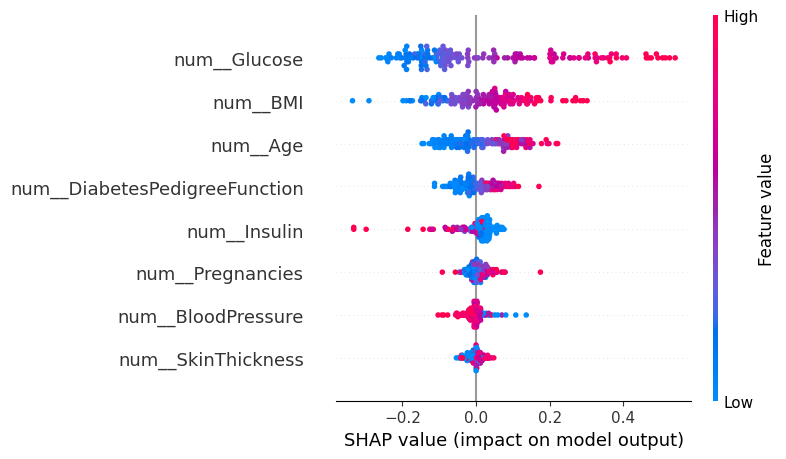

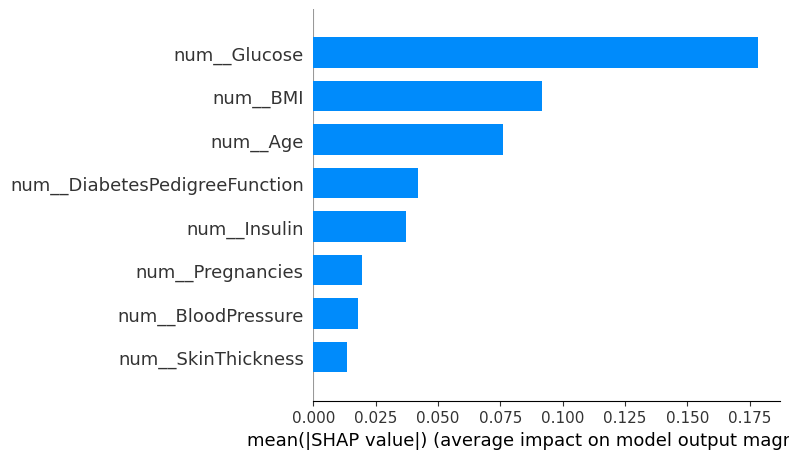

Saved: outputs_diabetes/diabetes_shap_summary.pdf/png and outputs_diabetes/diabetes_shap_bar.pdf/png


In [15]:
# =========================
# FULL PIPELINE — Diabetes (robust on older sklearn)
# - preprocess (handles bool/bool nullable + categoricals)
# - train Keras NN
# - compute SHAP (KernelExplainer)
# - export high-quality figures (PDF + PNG)
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

OUTPUT_DIR = "outputs_diabetes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------
# 0) Assumes you already have:
# X_train, X_test, y_train, y_test
# -------------------------

# -------------------------
# 1) Coerce boolean-like columns to numeric
# -------------------------
X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

# -------------------------
# 2) Identify numeric vs categorical columns AFTER coercion
# -------------------------
num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

# -------------------------
# 3) Build preprocessing pipelines
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

# IMPORTANT: only include transformers that actually have columns
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------
# 4) Fit/transform preprocessing
# -------------------------
X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

# -------------------------
# 5) Robust feature names extraction (guards for empty categoricals)
# -------------------------
def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    # Newer sklearn: easiest
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()

    # Older sklearn: manual, but only if pieces exist
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])

    if len(cat_cols) > 0:
        # Use fitted transformers_ (underscore!) which exists after fit
        # Find the fitted 'cat' transformer
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break

        if fitted_cat is not None:
            # If pipeline, grab final OneHotEncoder
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat

            # Only call if actually fitted (has categories_)
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())

    return names

feature_names = get_feature_names_fitted(preprocess, num_cols, cat_cols)

# Sanity check
assert len(feature_names) == X_train_p.shape[1], (
    f"Feature name mismatch: {len(feature_names)} vs {X_train_p.shape[1]}"
)
print("Features:", len(feature_names))

# -------------------------
# 6) Train NN
# -------------------------
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
 )

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

# -------------------------
# 7) SHAP (KernelExplainer)
# -------------------------
rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

# -------------------------
# 8) Export high-quality plots
# -------------------------
# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_summary.pdf", bbox_inches="tight")          # best for papers (vector)
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_summary.png", dpi=600, bbox_inches="tight") # best for slides/posters
plt.show()

# Bar summary
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/diabetes_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/diabetes_shap_summary.pdf/png and {OUTPUT_DIR}/diabetes_shap_bar.pdf/png")


In [16]:
# ── Save SHAP ranking to CSV (Diabetes) ──
import numpy as np, pandas as pd, os

_OUTPUT_DIR_DIAB = 'outputs_diabetes'
os.makedirs(_OUTPUT_DIR_DIAB, exist_ok=True)

_shap_vals_diab = np.array(shap_values)
_mean_abs_diab  = np.abs(_shap_vals_diab).mean(axis=0)
_shap_ranking_diab = sorted(
    zip(feature_names, _mean_abs_diab),
    key=lambda x: -x[1]
)
_shap_df_diab = pd.DataFrame(_shap_ranking_diab, columns=['Feature', 'SHAP_Score'])
_shap_df_diab['SHAP_Rank'] = range(1, len(_shap_df_diab) + 1)
_shap_df_diab.to_csv(f'{_OUTPUT_DIR_DIAB}/shap_ranking.csv', index=False)
print('SHAP Ranking (Diabetes):')
print(_shap_df_diab.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_DIAB}/shap_ranking.csv')


SHAP Ranking (Diabetes):
                      Feature  SHAP_Score  SHAP_Rank
                 num__Glucose    0.178194          1
                     num__BMI    0.091769          2
                     num__Age    0.075933          3
num__DiabetesPedigreeFunction    0.041802          4
                 num__Insulin    0.036923          5
             num__Pregnancies    0.019343          6
           num__BloodPressure    0.018042          7
           num__SkinThickness    0.013357          8
Saved: outputs_diabetes/shap_ranking.csv


### COMPAS Recidivism

In [17]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)

# ProPublica standard filtering
df = raw[
    (raw['days_b_screening_arrest'] <= 30) &
    (raw['days_b_screening_arrest'] >= -30) &
    (raw['is_recid'] != -1) &
    (raw['c_charge_degree'] != 'O') &
    (raw['score_text'] != 'N/A')
].copy()

# Feature engineering
df['race_black']      = (df['race'] == 'African-American').astype(int)
df['juv_any']         = ((df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']) > 0).astype(int)
df['sex']             = (df['sex'] == 'Male').astype(int)
df['c_charge_degree'] = (df['c_charge_degree'] == 'F').astype(int)

print(f"Rows after filtering: {len(df)}")
print(f"Recidivism rate: {df['two_year_recid'].mean():.1%}")
df[['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any', 'two_year_recid']].head()

Rows after filtering: 6172
Recidivism rate: 45.5%


,age,sex,race_black,priors_count,c_charge_degree,juv_any,two_year_recid
0,69,1,0,0,1,0,0
1,34,1,1,0,1,0,1
2,24,1,1,4,1,1,1
5,44,1,0,0,0,0,0
6,41,1,0,14,1,0,1


In [18]:
from sklearn.model_selection import train_test_split

features = ['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any']
target   = 'two_year_recid'

X = df[features].dropna()
y = df.loc[X.index, target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_compas = DecisionTreeClassifier(max_depth=5, random_state=42)
model_compas.fit(X_train, y_train)

y_pred = model_compas.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", features)

Accuracy: 0.6623481781376518
Feature columns: ['age', 'sex', 'race_black', 'priors_count', 'c_charge_degree', 'juv_any']


In [20]:
import os
from sklearn.tree import export_graphviz
import graphviz
import shutil

OUTPUT_DIR = "outputs_compas"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model_compas,
    out_file=None,
    feature_names=features,
    class_names=["No Recidivism", "Recidivism"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)

if shutil.which("dot") is None:
    out_path = f"{OUTPUT_DIR}/compas_tree.dot"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(dot)
    print("Graphviz not found in PATH. Saved DOT:", out_path)
else:
    graph.render(f"{OUTPUT_DIR}/compas_tree", format="png", cleanup=True)
    print(f"Saved: {OUTPUT_DIR}/compas_tree.png")

Graphviz not found in PATH. Saved DOT: outputs_compas/compas_tree.dot


#### COMPAS — Neural Network + SHAP

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_s, y_train)

print(f"Neural Network train accuracy: {accuracy_score(y_train, mlp.predict(X_train_s)):.4f}")
print(f"Neural Network test  accuracy: {accuracy_score(y_test,  mlp.predict(X_test_s)):.4f}")
print()
print(classification_report(y_test, mlp.predict(X_test_s), target_names=["No Recidivism", "Recidivism"]))

Neural Network train accuracy: 0.6929
Neural Network test  accuracy: 0.6648

               precision    recall  f1-score   support

No Recidivism       0.67      0.76      0.72       683
   Recidivism       0.65      0.54      0.59       552

     accuracy                           0.66      1235
    macro avg       0.66      0.65      0.65      1235
 weighted avg       0.66      0.66      0.66      1235



In [22]:
import shap
import matplotlib.pyplot as plt
import numpy as np

predict_fn = lambda x: mlp.predict_proba(scaler.transform(x))

background = shap.sample(X_train, 50, random_state=42).values
X_explain  = X_test.iloc[:100].values

explainer = shap.KernelExplainer(predict_fn, background)
shap_vals = explainer.shap_values(X_explain, nsamples=200)

# SHAP >= 0.46 returns 3D (n_samples, n_features, n_classes); older returns list
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals[:, :, 1]

print(f"SHAP values shape: {sv.shape}")
print("Mean |SHAP| per feature:")
for feat, imp in sorted(zip(features, np.abs(sv).mean(axis=0)), key=lambda x: -x[1]):
    print(f"  {feat:25s} {imp:.4f}")

c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  

SHAP values shape: (100, 6)
Mean |SHAP| per feature:
  priors_count              0.1512
  age                       0.0948
  c_charge_degree           0.0250
  sex                       0.0219
  race_black                0.0133
  juv_any                   0.0053


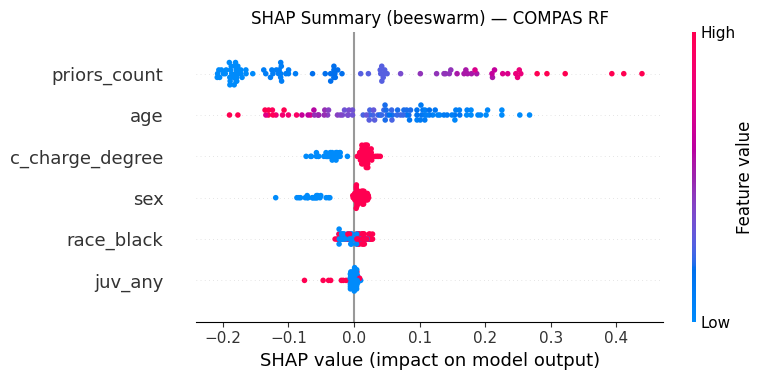

Saved: outputs_compas/compas_shap.png


In [23]:
plt.figure(figsize=(8, 5))
plot_features = X_explain
sv_plot = sv
if hasattr(plot_features, "shape"):
    n = min(plot_features.shape[0], sv_plot.shape[0])
    plot_features = plot_features[:n]
    sv_plot = sv_plot[:n]
shap.summary_plot(sv_plot, plot_features, feature_names=features, show=False)
plt.title("SHAP Summary (beeswarm) — COMPAS RF")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/compas_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/compas_shap.png")

#### COMPAS — LIME Explanations

In [24]:
import lime
import lime.lime_tabular

cat_cols = ['sex', 'race_black', 'c_charge_degree', 'juv_any']
cat_feature_idx = [i for i, c in enumerate(features) if c in cat_cols]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=features,
    class_names=['No Recidivism', 'Recidivism'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)

# predict_fn scales before passing to MLP
lime_predict_fn = lambda x: mlp.predict_proba(scaler.transform(x))


In [25]:
import numpy as np

X_test_arr  = X_test.values
test_labels = y_test.reset_index(drop=True)

# Pick one recidivist and one non-recidivist from the test set
recid_idx     = test_labels[test_labels == 1].index[0]
no_recid_idx  = test_labels[test_labels == 0].index[0]

print(f"Recidivist instance (test index {recid_idx}):")
print(dict(zip(features, X_test_arr[recid_idx])))
print(f"\nNon-recidivist instance (test index {no_recid_idx}):")
print(dict(zip(features, X_test_arr[no_recid_idx])))

Recidivist instance (test index 0):
{'age': np.int64(26), 'sex': np.int64(1), 'race_black': np.int64(1), 'priors_count': np.int64(13), 'c_charge_degree': np.int64(0), 'juv_any': np.int64(0)}

Non-recidivist instance (test index 1):
{'age': np.int64(31), 'sex': np.int64(1), 'race_black': np.int64(0), 'priors_count': np.int64(1), 'c_charge_degree': np.int64(0), 'juv_any': np.int64(1)}


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


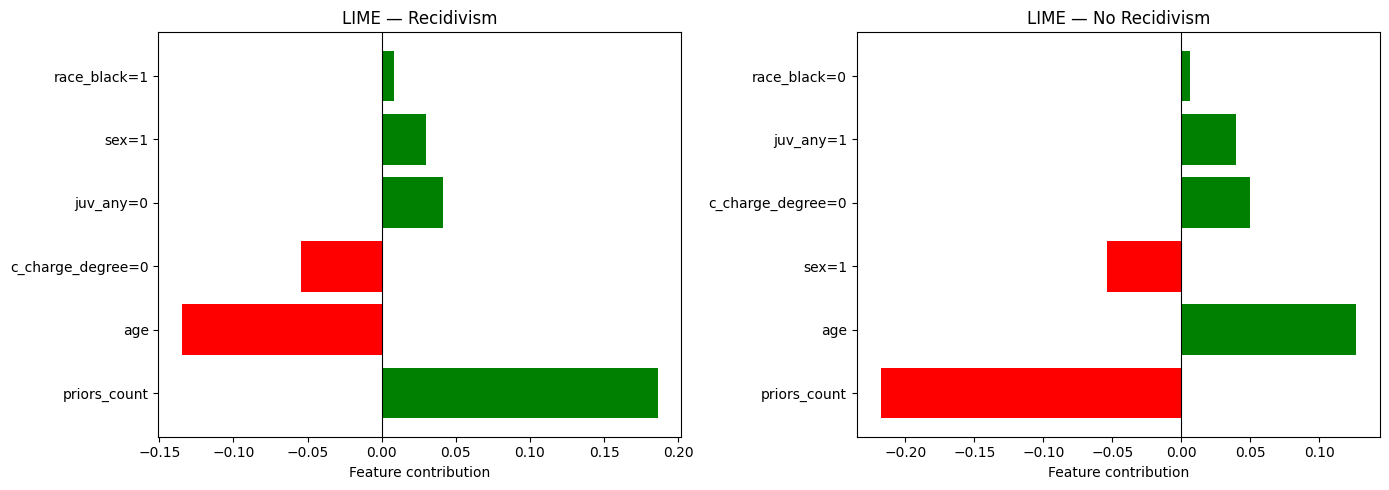

Saved: outputs_compas/compas_lime.png


In [26]:
import matplotlib.pyplot as plt

exp_recid = lime_explainer.explain_instance(
    X_test_arr[recid_idx],
    lime_predict_fn,
    num_features=len(features),
    labels=(0, 1)
)

exp_no_recid = lime_explainer.explain_instance(
    X_test_arr[no_recid_idx],
    lime_predict_fn,
    num_features=len(features),
    labels=(0, 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_recid,    1, "Recidivism"),
    (axes[1], exp_no_recid, 0, "No Recidivism"),
]:
    vals     = exp.as_list(label=label_idx)
    feats, weights = zip(*vals)
    colors   = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(feats, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/compas_lime.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/compas_lime.png")

### Heart Disease (UCI)


In [27]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# ==========================================
# DATA LOADING & PREP (UCI Heart Disease)
# ==========================================
# Fetch dataset (ID 45)
heart_disease = fetch_ucirepo(id=45)

# Extract features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

# Target variable is 'num' (0 = no disease, 1-4 = has disease).
# Convert the 'num' variable directly to binary form (0 and 1) without changing its name.
df['num'] = (df['num'] > 0).astype(int)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [28]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'num'


In [29]:
df = df.dropna(subset=['num'])
df.shape


(303, 14)

In [30]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [32]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Feature columns:", list(X.columns))


Accuracy: 0.7540983606557377
Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [33]:
from sklearn.tree import export_graphviz
import graphviz
import shutil

OUTPUT_DIR = "outputs_heart_disease"
os.makedirs(OUTPUT_DIR, exist_ok=True)

dot = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot)
graph.render(f"{OUTPUT_DIR}/heart_disease_tree", format="png", cleanup=True)
print(f"Saved: {OUTPUT_DIR}/heart_disease_tree.png")

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

### Heart Disease — LIME Explanations


In [ ]:
!pip install lime


In [ ]:
import lime
import lime.lime_tabular

# Heart Disease has mostly numeric features — no categorical dummies
cat_feature_idx = []

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    categorical_features=cat_feature_idx,
    mode='classification',
    random_state=42,
    discretize_continuous=False
)


In [ ]:
test_labels = y_test.reset_index(drop=True)
X_test_arr = X_test.values
feature_names_hd = X_train.columns.tolist()

# Pick one disease and one no-disease instance from the test set
disease_idx    = test_labels[test_labels == 1].index[0]
no_disease_idx = test_labels[test_labels == 0].index[0]

print(f"Disease instance (test index {disease_idx}):")
print(dict(zip(feature_names_hd, X_test_arr[disease_idx])))
print(f"\nNo-disease instance (test index {no_disease_idx}):")
print(dict(zip(feature_names_hd, X_test_arr[no_disease_idx])))


Disease instance (test index 1):
{'age': np.float64(54.0), 'sex': np.float64(1.0), 'cp': np.float64(4.0), 'trestbps': np.float64(110.0), 'chol': np.float64(206.0), 'fbs': np.float64(0.0), 'restecg': np.float64(2.0), 'thalach': np.float64(108.0), 'exang': np.float64(1.0), 'oldpeak': np.float64(0.0), 'slope': np.float64(2.0), 'ca': np.float64(1.0), 'thal': np.float64(3.0)}

No-disease instance (test index 0):
{'age': np.float64(53.0), 'sex': np.float64(1.0), 'cp': np.float64(3.0), 'trestbps': np.float64(130.0), 'chol': np.float64(246.0), 'fbs': np.float64(1.0), 'restecg': np.float64(2.0), 'thalach': np.float64(173.0), 'exang': np.float64(0.0), 'oldpeak': np.float64(0.0), 'slope': np.float64(1.0), 'ca': np.float64(3.0), 'thal': np.float64(3.0)}


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


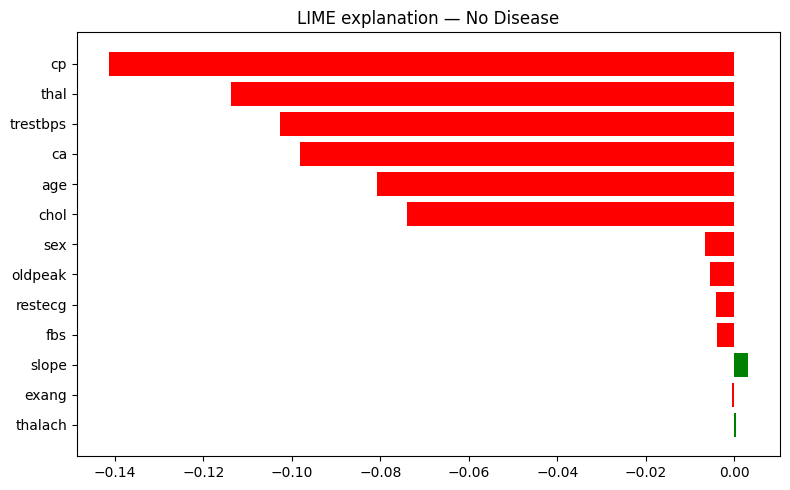

In [ ]:
import matplotlib.pyplot as plt

exp_no_disease = lime_explainer.explain_instance(
    X_test_arr[no_disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_no_disease.as_pyplot_figure(label=0)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — No Disease")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_no_disease.png", dpi=150)
plt.show()


c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


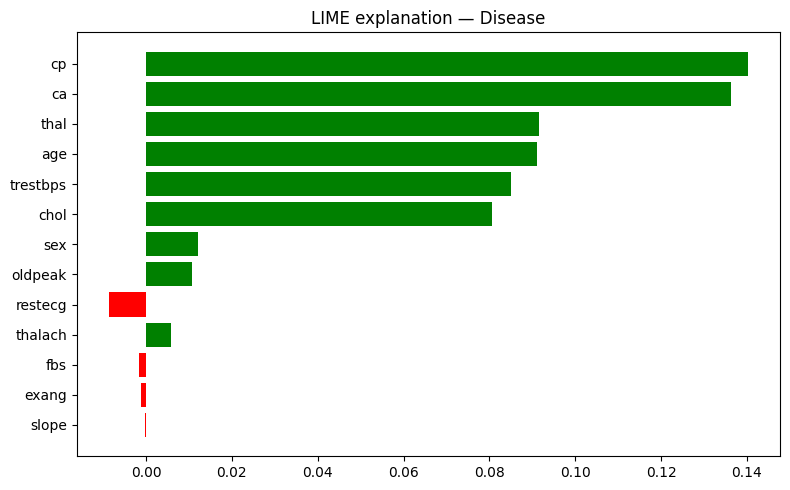

In [ ]:
exp_disease = lime_explainer.explain_instance(
    X_test_arr[disease_idx],
    model.predict_proba,
    num_features=len(X_train.columns),
    labels=(0, 1)
)

fig = exp_disease.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title("LIME explanation — Disease")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_disease.png", dpi=150)
plt.show()


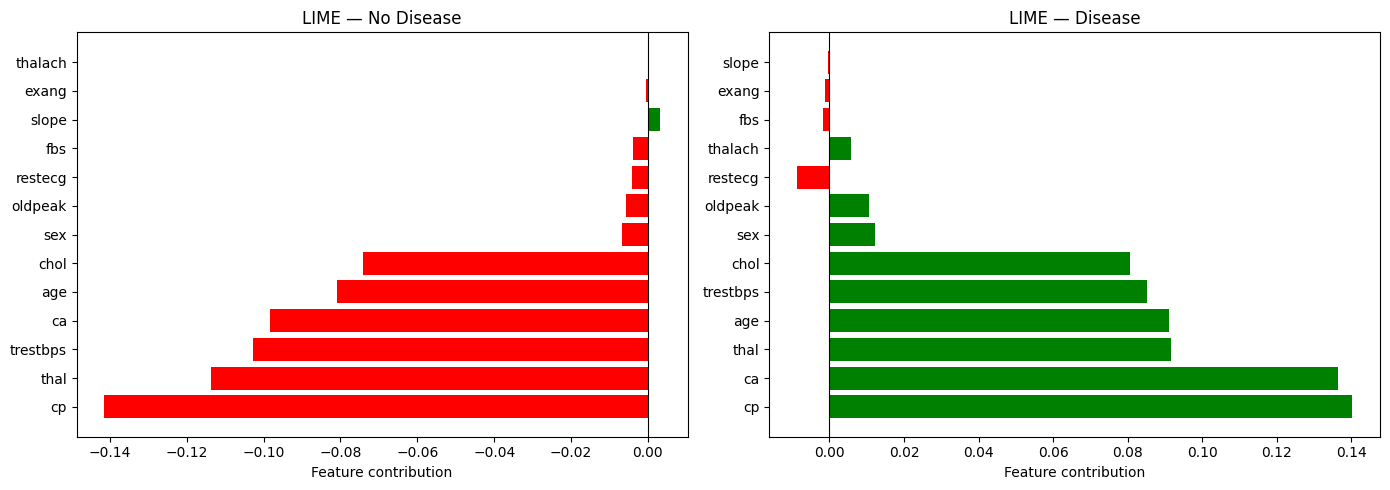

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, label_idx, title in [
    (axes[0], exp_no_disease, 0, "No Disease"),
    (axes[1], exp_disease,    1, "Disease"),
]:
    vals = exp.as_list(label=label_idx)
    features_l, weights = zip(*vals)
    colors = ['green' if w > 0 else 'red' for w in weights]
    ax.barh(features_l, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME — {title}")
    ax.set_xlabel("Feature contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_lime_comparison.png", dpi=150)
plt.show()


#### Heart Disease — LIME Global Ranking (multi-instance)


In [ ]:
# ── LIME Global Ranking: aggregate over 50 test instances (Heart Disease) ──
import re, numpy as np, pandas as pd, os

_OUTPUT_DIR_HD = 'outputs_heart_disease'
_N_LIME_HD = min(50, len(X_test_arr))

_feat_set_hd = set(feature_names_hd)

def _parse_lime_feature(condition_str, known_features):
    """Extract the base feature name from a LIME condition string."""
    for feat in sorted(known_features, key=len, reverse=True):
        if condition_str.startswith(feat):
            return feat
    parts = re.split(r'[<>=!]', condition_str)
    return parts[0].strip()

_lime_global_hd = {}
for _i in range(_N_LIME_HD):
    _exp = lime_explainer.explain_instance(
        X_test_arr[_i],
        model.predict_proba,
        num_features=len(feature_names_hd),
        labels=(0, 1)
    )
    for _cond, _w in _exp.as_list(label=1):
        _fname = _parse_lime_feature(str(_cond), _feat_set_hd)
        _lime_global_hd.setdefault(_fname, []).append(abs(_w))

_lime_ranking_hd = sorted(
    [(_f, sum(_ws) / len(_ws)) for _f, _ws in _lime_global_hd.items()],
    key=lambda x: -x[1]
)
_lime_df_hd = pd.DataFrame(_lime_ranking_hd, columns=['Feature', 'LIME_Score'])
_lime_df_hd['LIME_Rank'] = range(1, len(_lime_df_hd) + 1)
_lime_df_hd.to_csv(f'{_OUTPUT_DIR_HD}/lime_global_ranking.csv', index=False)
print(f'LIME Global Ranking (Heart Disease, N={_N_LIME_HD} instances):')
print(_lime_df_hd.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_HD}/lime_global_ranking.csv')



FULL PIPELINE — Heart Disease (robust on older sklearn)
- preprocess (handles bool/bool nullable + categoricals)
- train Keras NN
- compute SHAP (KernelExplainer)
- export high-quality figures (PDF + PNG)


Features: 13
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6062 - auc: 0.5743 - loss: 0.6825 - val_accuracy: 0.6327 - val_auc: 0.7058 - val_loss: 0.6417
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6788 - auc: 0.7336 - loss: 0.6241 - val_accuracy: 0.7347 - val_auc: 0.7951 - val_loss: 0.5984
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7409 - auc: 0.8121 - loss: 0.5814 - val_accuracy: 0.7143 - val_auc: 0.8325 - val_loss: 0.5617
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7824 - auc: 0.8627 - loss: 0.5419 - val_accuracy: 0.7551 - val_auc: 0.8537 - val_loss: 0.5274
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7876 - auc: 0.8651 - loss: 0.5146 - val_accuracy: 0.7755 - val_auc: 0.8639 - val_loss: 0.4978
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7617 - auc: 0.8720 - loss: 0.4937 - val_accuracy: 0.7959 - val_auc: 0.8707 - val_loss: 0.4731
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/s

100%|██████████| 61/61 [01:26<00:00,  1.42s/it]


SHAP values shape: (61, 13)


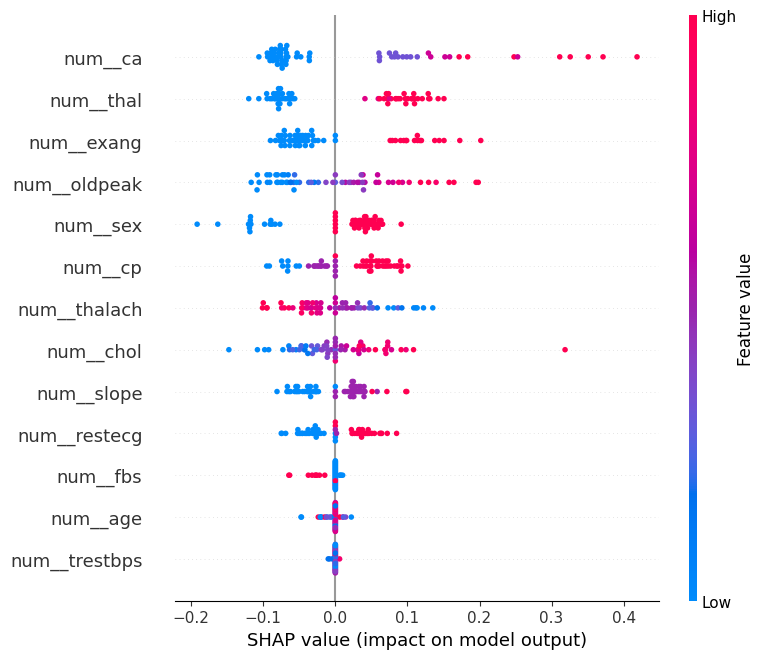

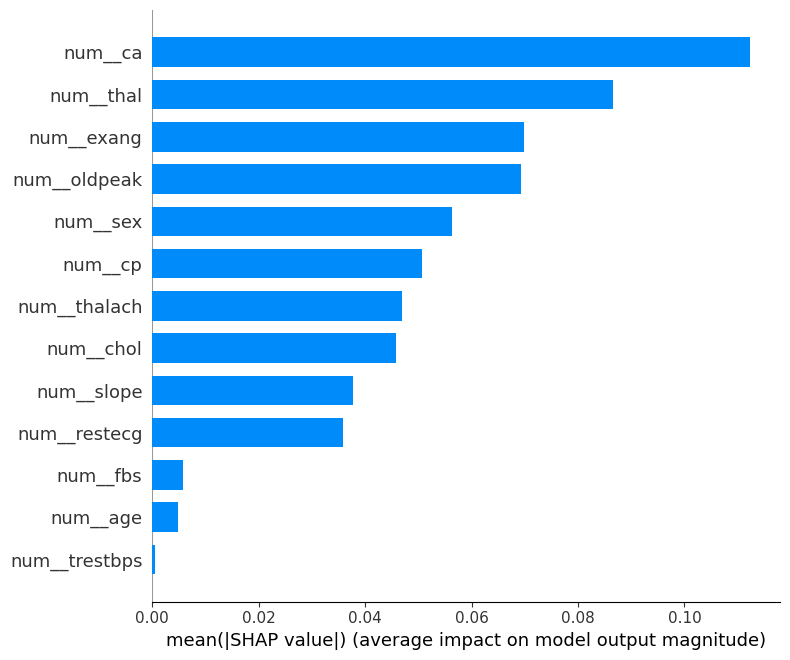

Saved: outputs_heart_disease/heart_disease_shap_summary.pdf/png and outputs_heart_disease/heart_disease_shap_bar.pdf/png


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

OUTPUT_DIR = "outputs_heart_disease"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------
# 0) Assumes you already have:
# X_train, X_test, y_train, y_test
# -------------------------

# -------------------------
# 1) Coerce boolean-like columns to numeric
# -------------------------
X_train_ = X_train.copy()
X_test_  = X_test.copy()

bool_like_cols = X_train_.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_like_cols:
    X_train_[bool_like_cols] = X_train_[bool_like_cols].astype("float64")
    X_test_[bool_like_cols]  = X_test_[bool_like_cols].astype("float64")

# -------------------------
# 2) Identify numeric vs categorical columns AFTER coercion
# -------------------------
num_cols = X_train_.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_.select_dtypes(include=["object", "category"]).columns.tolist()

# -------------------------
# 3) Build preprocessing pipelines
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _make_ohe()),
])

# IMPORTANT: only include transformers that actually have columns
transformers = []
if len(num_cols) > 0:
    transformers.append(("num", numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(("cat", categorical_pipe, cat_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------
# 4) Fit/transform preprocessing
# -------------------------
X_train_p = preprocess.fit_transform(X_train_)
X_test_p  = preprocess.transform(X_test_)

X_train_p = X_train_p.astype(np.float32)
X_test_p  = X_test_p.astype(np.float32)

# -------------------------
# 5) Robust feature names extraction (guards for empty categoricals)
# -------------------------
def get_feature_names_fitted(ct: ColumnTransformer, num_cols, cat_cols):
    # Newer sklearn: easiest
    if hasattr(ct, "get_feature_names_out"):
        return ct.get_feature_names_out().tolist()

    # Older sklearn: manual, but only if pieces exist
    names = []
    if len(num_cols) > 0:
        names.extend([str(c) for c in num_cols])

    if len(cat_cols) > 0:
        # Use fitted transformers_ (underscore!) which exists after fit
        # Find the fitted 'cat' transformer
        fitted_cat = None
        for name, trans, cols in ct.transformers_:
            if name == "cat":
                fitted_cat = trans
                break

        if fitted_cat is not None:
            # If pipeline, grab final OneHotEncoder
            ohe = fitted_cat.named_steps["onehot"] if hasattr(fitted_cat, "named_steps") else fitted_cat

            # Only call if actually fitted (has categories_)
            if hasattr(ohe, "categories_"):
                if hasattr(ohe, "get_feature_names_out"):
                    names.extend(ohe.get_feature_names_out(cat_cols).tolist())
                else:
                    names.extend(ohe.get_feature_names(cat_cols).tolist())

    return names

feature_names = get_feature_names_fitted(preprocess, num_cols, cat_cols)

# Sanity check
assert len(feature_names) == X_train_p.shape[1], (
    f"Feature name mismatch: {len(feature_names)} vs {X_train_p.shape[1]}"
)
print("Features:", len(feature_names))

# -------------------------
# 6) Train NN
# -------------------------
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
 )

history = model_keras.fit(
    X_train_p, y_train.to_numpy(),
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

print("Test metrics:", model_keras.evaluate(X_test_p, y_test.to_numpy(), verbose=0))

# -------------------------
# 7) SHAP (KernelExplainer)
# -------------------------
rng = np.random.default_rng(42)

bg_size = min(100, X_train_p.shape[0])
bg_idx = rng.choice(X_train_p.shape[0], size=bg_size, replace=False)
X_bg = X_train_p[bg_idx]

explain_size = min(200, X_test_p.shape[0])
X_explain = X_test_p[:explain_size]

def predict_proba(X):
    return model_keras.predict(X, verbose=0).reshape(-1)

explainer = shap.KernelExplainer(predict_proba, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=300)
shap_values = np.array(shap_values)

print("SHAP values shape:", shap_values.shape)

# -------------------------
# 8) Export high-quality plots
# -------------------------
# Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_summary.pdf", bbox_inches="tight")          # best for papers (vector)
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_summary.png", dpi=600, bbox_inches="tight") # best for slides/posters
plt.show()

# Bar summary
plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_bar.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/heart_disease_shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_DIR}/heart_disease_shap_summary.pdf/png and {OUTPUT_DIR}/heart_disease_shap_bar.pdf/png")


In [ ]:
# ── Save SHAP ranking to CSV (Heart Disease) ──
import numpy as np, pandas as pd, os

_OUTPUT_DIR_HD = 'outputs_heart_disease'
os.makedirs(_OUTPUT_DIR_HD, exist_ok=True)

_shap_vals_hd  = np.array(shap_values)
_mean_abs_hd   = np.abs(_shap_vals_hd).mean(axis=0)
_shap_ranking_hd = sorted(
    zip(feature_names, _mean_abs_hd),
    key=lambda x: -x[1]
)
_shap_df_hd = pd.DataFrame(_shap_ranking_hd, columns=['Feature', 'SHAP_Score'])
_shap_df_hd['SHAP_Rank'] = range(1, len(_shap_df_hd) + 1)
_shap_df_hd.to_csv(f'{_OUTPUT_DIR_HD}/shap_ranking.csv', index=False)
print('SHAP Ranking (Heart Disease):')
print(_shap_df_hd.to_string(index=False))
print(f'Saved: {_OUTPUT_DIR_HD}/shap_ranking.csv')
